# Fitting of EPR Spectra with MaRs - Advance

This notebook demonstrates how to use the Mars library to fit experimental EPR spectra by optimizing Hamiltonian (or other) parameters.

In this notebook, we examine real data recorded on the Elexis EPR spectrometer. We aim to complete the entire fitting cycle from start to finish for multi-spectra fitting with user-defined parameters


\
\
\
\
\
\
For any questions, please contact Arkady Samsonenko via: \
Telegram: @Arkady_Samsonenko \
Email: a.samsonenko.tomo.nsc.ru\
\
\
\
The last notebook update: 2026.08.03

In [1]:
# Import necessary libraries
import sys
import os
import math

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

import optuna
import nevergrad as ng

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

# Import Mars library components
import mars
from mars import spin_model, spectra_manager, mesher, constants
from mars import utils
from mars.optimization import ParameterSpace, ParamSpec, SpectrumFitter, SpaceSearcher, print_trial_results

Some stuff might fail: issue in joblib
[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


In [2]:
dtype = torch.float64
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# 1. Introduction

The EPR data that we want to fit is described in [Dalton Trans., 2025,54, 15176-15187]. We will work with real experimental data on a copper(II) nitroxide chain complex, which undergoes a magnetic transition in the temperature range 90-120 K, causing changes in the environment of copper ion and, consequently, in the g-tensor.


We will complete the entire fitting workflow:

1) Loading and preprocessing experimental EPR data
2) Setting up a spin system model
3) Implementing multi-spectrum simultaneous fitting
4) Analyzing and validating the best-fit parameters

# 2.Loading and Preprocessing Experimental Data

MaRs has some additional functions to prepare data to computations study. We consider spectra under two temperatures: 96K and 136K - temperatures below and above transition

In [3]:
path_96K = r"data/KY3_96K"
path_136K = r"data/KY3_136K"

data_96K = mars.read_bruker_data(path_96K)
data_136K = mars.read_bruker_data(path_136K)

# the output consist of the spectrometer experimental parmeters and x and y values

data_96K[1]["x_values"] = data_96K[1]["x_values"] / 1e4
data_136K[1]["x_values"] = data_136K[1]["x_values"] / 1e4  # From Gauss to Tesla ransformation

Let's perform some simple data preparation:

1) Removing the baseline
2) Normalizing the spectra

In [4]:
areas = ((0.0, 1.0), (1.35, 1.5))  # area of baselines where spectra is missed. Indeed, MaRs can automatically determine the baseline area if you do not put it.

y_values, _ = mars.spectra_processing.correct_baseline(data_96K[1]["x_values"], data_96K[1]["y_values"], areas, poly_order=1)
y_values = y_values / max(y_values)
# Make the tata is more informative and save only spectra
data_96K[1]["x_values"] = data_96K[1]["x_values"][300:-300]
data_96K[1]["y_values"] = y_values[300:-300]
freq_96K = data_96K[0]["MWFQ"]


y_values, _ = mars.spectra_processing.correct_baseline(data_136K[1]["x_values"], data_136K[1]["y_values"], areas, poly_order=1)
y_values = y_values / max(y_values)
# Make the tata is more informative and save only spectra
data_136K[1]["x_values"] = data_136K[1]["x_values"][300:-300]
data_136K[1]["y_values"] = y_values[300:-300]
freq_136K = data_136K[0]["MWFQ"]

# Also spectra_processing has other methods to perform some simple processing. Here we considered the most easy way to subscribe baseline

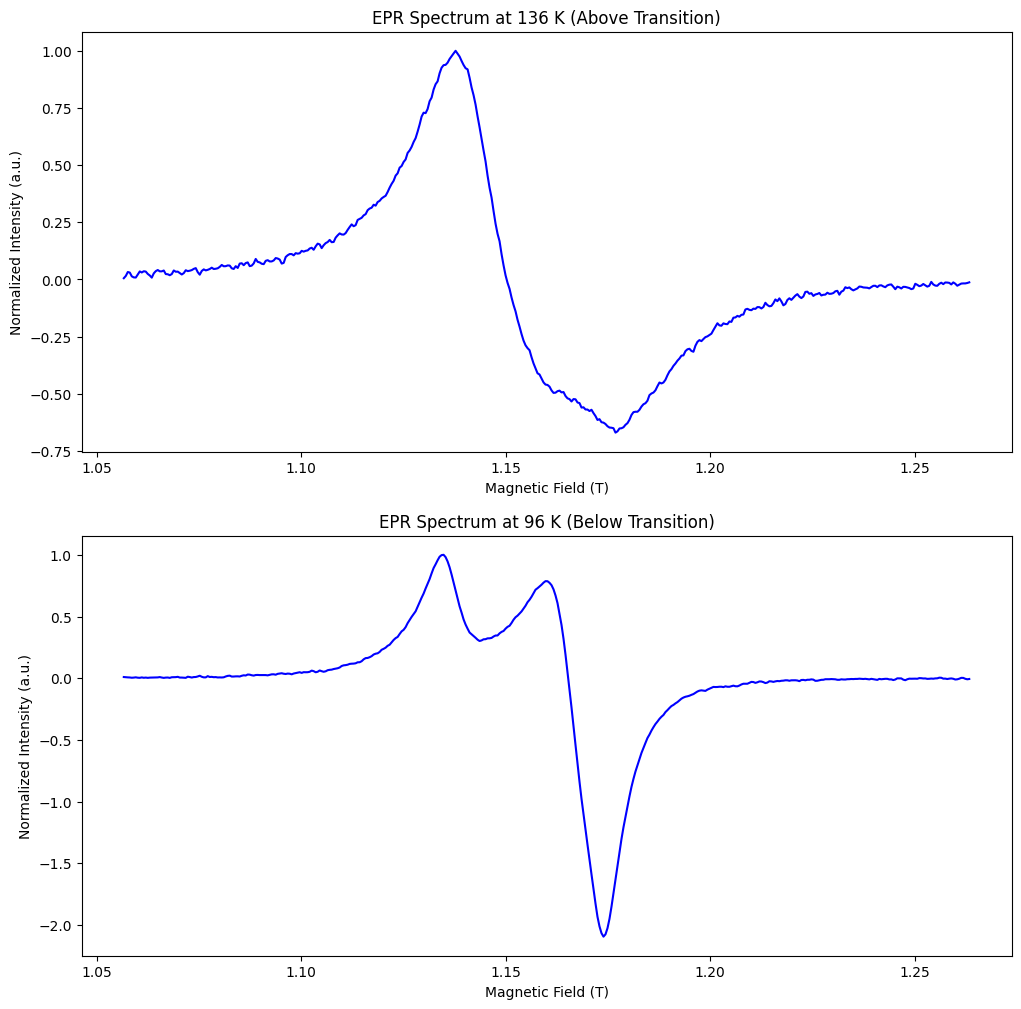

In [5]:
plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)
plt.plot(data_96K[1]["x_values"], data_96K[1]["y_values"], 'b-', linewidth=1.5)
plt.title(f'EPR Spectrum at 136 K (Above Transition)', fontsize=12)
plt.xlabel('Magnetic Field (T)', fontsize=10)
plt.ylabel('Normalized Intensity (a.u.)', fontsize=10)

plt.subplot(2, 1, 2)
plt.plot(data_136K[1]["x_values"], data_136K[1]["y_values"], 'b-', linewidth=1.5)
plt.title(f'EPR Spectrum at 96 K (Below Transition)', fontsize=12)
plt.xlabel('Magnetic Field (T)', fontsize=10)
plt.ylabel('Normalized Intensity (a.u.)', fontsize=10)

plt.show()

# 3. Spin System Modeling
### 3.1 Physical Model of the System

The original sample from the article [Dalton Trans., 2025,54, 15176-15187] is chain with repeating units. We will model this chain using only one unit.

**Each unit can be modeled as a system with three interacting spins:** \
Nitroxide radical electron (S = 1/2) \
Chain copper ion (S = 1/2) \
Branching copper ion (S = 1/2)

The magnetic transition affects primarily the g-tensor of the branching copper ion and exchange interaction values between paramagnetic ions

**We need to define a model that accounts for:** \
Different g-tensors for branching copper ions above and below the transition \
The same g-tensors for chain copper ions \
Exchange interactions between spins \
Orientation relationships between chain and branching g-tensors


The transition induces a reorientation of the g-tensor at the branching site. While this could be modeled explicitly using three Euler angles, we adopt a simpler approach:  
we allow the individual components $g_x$, $g_y$, and $g_z$ of the branching coppers g-tensor to vary, while keeping the mean-square value

$$
\langle g^2 \rangle = \frac{g_x^2 + g_y^2 + g_z^2}{3}
$$

approximately constant across the transition. This preserves the overall magnitude of the g-tensor while capturing the anisotropy changes linked to the structural rearrangement.

### 3.2 Creating the parameter space

1) We need to define the fixed parameters.  
According to the article, the exchange interactions and the angles between the branching and chain copper ions are known from quantum chemistry calculations.

2) Define varying parameters:  

In [6]:
# Let's start from fixed parameters


# Initialize dictionary for fixed parameters
fixed_parameters = {}

# g-value for nitroxide radical (relatively constant)
fixed_parameters["g_rad"] = 2.002

# Exchange interactions above the transition (in cm-1)
fixed_parameters["J_chain_high_temp"] = 1.4     # Chain copper-nitroxide interaction
fixed_parameters["J_branching_high_temp"] = -4.21  # Branching copper-nitroxide interaction

# Exchange interactions below the transition (in cm-1)
fixed_parameters["J_chain_low_temp"] = 1.9
fixed_parameters["J_branching_low_temp"] = -0.23


# Orientation matrices defining relative orientations of copper sites
# These are determined from crystal structure data
orient_branching = torch.tensor([
    [0.8859114, 0.0008034, 0.4638538],
    [0.0005397, -0.9999996, 0.0007013],
    [0.4638541, -0.000371, -0.8859115]
])

orient_chain = torch.tensor([
    [0.744169, 0.4552341, -0.4888501],
    [0.3236334, -0.8859029, -0.3323212],
    [-0.5843577, 0.0890949, -0.8065904]
])

fixed_parameters["orient_branching"] = orient_branching
fixed_parameters["orient_chain"] = orient_chain

In [7]:
# Initialize list for parameters to optimize
varies_parameters = [
    
    # g-tensor components for intrachain copper (x, y, z directions)
    ParamSpec("g_cu_chain_x", (2.0, 2.14), 2.025),
    ParamSpec("g_cu_chain_y", (2.0, 2.14), 2.05),
    ParamSpec("g_cu_chain_z", (2.20, 2.30), 2.25),
    
    # g-tensor components for branching copper above transition
    ParamSpec("g_cu_branching_high_temp_x", (2.0, 2.30), 2.07),
    ParamSpec("g_cu_branching_high_temp_y", (2.0, 2.30), 2.14),
    ParamSpec("g_cu_branching_high_temp_z", (2.0, 2.30), 2.26),
    
    # g-tensor components for branching copper below transition (x and z components)
    # y-component will be calculated to maintain constant average g-value
    ParamSpec("g_cu_branching_low_temp_x", (2.0, 2.30), 2.19),
    ParamSpec("g_cu_branching_low_temp_z", (2.0, 2.30), 2.07),
    
    # Delta g parameter to maintain <g²> conservation between phases
    ParamSpec("delta_g", (-0.01, 0.01), 0.0),
    
    # Line broadening parameters for high temperature spectrum
    ParamSpec("lorentz_high_temp", (0.00, 0.02), 0.001),
    ParamSpec("ham_strain_high_temp", (1e8, 1e9), 5e8),
    
    # Line broadening parameters for low temperature spectrum
    ParamSpec("lorentz_low_temp", (0.00, 0.02), 0.001),
    ParamSpec("ham_strain_low_temp", (1e8, 1e9), 5e8)
]

param_space = ParameterSpace(varies_parameters, fixed_parameters)
print(param_space)

____Fixed parameters_____ 
----------------------------------------
  g_rad                 =          2.0020
  J_chain_high_temp     =          1.4000
  J_branching_high_temp =         -4.2100
  J_chain_low_temp      =          1.9000
  J_branching_low_temp  =         -0.2300
  orient_branching      = tensor([[ 8.8591e-01,  8.0340e-04,  4.6385e-01],
        [ 5.3970e-04, -1.0000e+00,  7.0130e-04],
        [ 4.6385e-01, -3.7100e-04, -8.8591e-01]])
  orient_chain          = tensor([[ 0.7442,  0.4552, -0.4889],
        [ 0.3236, -0.8859, -0.3323],
        [-0.5844,  0.0891, -0.8066]])


______Varying parameters_____ 
----------------------------------------
  g_cu_chain_x               =          2.0250   (low:   +2.0000  up:   +2.1400)
  g_cu_chain_y               =          2.0500   (low:   +2.0000  up:   +2.1400)
  g_cu_chain_z               =          2.2500   (low:   +2.2000  up:   +2.3000)
  g_cu_branching_high_temp_x =          2.0700   (low:   +2.0000  up:   +2.3000)
  g_cu_branc

The number of parameters to be varied is truly large. Of course, we encounter overfitting of the g-tensor values. However, we have the ability to search the parameter space for the most physically reasonable values for our case.

In [8]:
def build_sample(J_chain, J_branching, g_rad, g_cu_chain, g_cu_branching, 
                 orient_chain, orient_branching, ham_strain, lorentz):
    """
    Build a spin system sample with specified parameters
    Parameters:
    -----------
    J_chain, J_branching : float
        Exchange interaction parameters (in cm^-1)
    g_rad : float
        g-value for nitroxide radical
    g_cu_chain, g_cu_branching : torch.Tensor
        g-tensor components for chain and branching copper sites
    orient_chain, orient_branching : torch.Tensor
        Orientation matrices for copper sites
    ham_strain : float
        Hamiltonian strain parameter
    lorentz : float
        Lorentzian line broadening parameter
    Returns:
    --------
    sample : spin_model.MultiOrientedSample
    """
    # Create g-tensor interactions
    zeem_chain = spin_model.Interaction(g_cu_chain, frame=orient_chain, dtype=dtype, device=device)
    zeem_branching = spin_model.Interaction(g_cu_branching, frame=orient_branching, dtype=dtype, device=device)
    zeem_rad = spin_model.Interaction(g_rad)
    
    e_chain = mars.particles.Electron(spin=0.5)
    e_branching = mars.particles.Electron(spin=0.5)
    e_rad = mars.particles.Electron(spin=0.5)

    ee_int_branching = spin_model.Interaction(-2 * constants.unit_converter(J_branching, "cm-1_to_Hz"), dtype=dtype, device=device)
    ee_int_chain = spin_model.Interaction(-2 * constants.unit_converter(J_chain, "cm-1_to_Hz"), dtype=dtype, device=device)
    
    # Build the complete spin system
    system = spin_model.SpinSystem(
        electrons=[e_rad, e_chain, e_branching],
        g_tensors=[zeem_rad, zeem_chain, zeem_branching],
        electron_electron=[
            (0, 1, ee_int_chain),  # Nitroxide - chain copper
            (0, 2, ee_int_branching)  # Nitroxide - branching copper
        ], dtype=dtype, device=device
    )
    
    # Create multi-oriented sample
    return spin_model.MultiOrientedSample(
        base_spin_system=system, 
        ham_strain=ham_strain,
        gauss=0,                     # No Gaussian broadening
        lorentz=lorentz,             # Lorentzian broadening
        dtype=dtype,
        device=device
    )

In [9]:
def build_two_samples(params):
    """
    Create spin system samples for both temperature
    
    Parameters:
    -----------
    params : dict
        Current parameter values from optimization
    Returns:
    --------
    sample_high_temp, sample_low_temp : spin_model.MultiOrientedSample
    """
    # Extract g-tensor components for interchain copper
    g_cu_chain = torch.tensor([
        params["g_cu_chain_x"],
        params["g_cu_chain_y"],
        params["g_cu_chain_z"]
    ])
    
    # Extract g-tensor components for branching copper above transition
    g_cu_branching_high_temp = torch.tensor([
        params["g_cu_branching_high_temp_x"],
        params["g_cu_branching_high_temp_y"],
        params["g_cu_branching_high_temp_z"]
    ])
    
    # Calculate g-tensor y-component for branching copper below transition
    # This maintains constant <g²> between phases with a small correction (delta_g)
    delta_g = params["delta_g"]
    g_cu_branching_low_temp_x = params["g_cu_branching_low_temp_x"]
    g_cu_branching_low_temp_z = params["g_cu_branching_low_temp_z"]
    
    # Calculate y-component to maintain constant <g²>
    g_cu_intra_sq = sum(g_cu_branching_high_temp**2)
    g_cu_branching_low_temp_y_sq = (
        g_cu_intra_sq - 
        g_cu_branching_low_temp_x**2 - 
        g_cu_branching_low_temp_z**2 + 
        delta_g
    )
    g_cu_branching_low_temp_y = max(0.0, g_cu_branching_low_temp_y_sq)**0.5
    
    # Create g-tensor for branching copper below transition
    g_cu_branching_low_temp = torch.tensor([
        g_cu_branching_low_temp_x,
        g_cu_branching_low_temp_y,
        g_cu_branching_low_temp_z
    ])
    
    # Create sample for high temperature 
    sample_high_temp = build_sample(
        J_chain=params["J_chain_high_temp"],
        J_branching=params["J_branching_high_temp"],
        g_rad=params["g_rad"],
        g_cu_chain=g_cu_chain,
        g_cu_branching=g_cu_branching_high_temp,
        orient_chain=params["orient_chain"],
        orient_branching=params["orient_branching"],
        ham_strain=params["ham_strain_high_temp"],
        lorentz=torch.tensor(params["lorentz_high_temp"]),
    )
    
    # Create sample for low temperature 
    sample_low_temp = build_sample(
        J_chain=params["J_chain_low_temp"],
        J_branching=params["J_branching_low_temp"],
        g_rad=params["g_rad"],
        g_cu_chain=g_cu_chain,
        g_cu_branching=g_cu_branching_low_temp,
        orient_chain=params["orient_chain"],
        orient_branching=params["orient_branching"],
        ham_strain=params["ham_strain_low_temp"],
        lorentz=torch.tensor(params["lorentz_low_temp"])
    )
    
    return sample_high_temp, sample_low_temp

# 4 Data Fitting
### 4.1 Creation of spactra simulator


Here we create a StationarySpectra object in the init method. Re-initializing each time doesn't take as long as it did in notebook example_3, but the current approach is better.

In [10]:
class SpectraSimulator:
    """Simulator class that generates EPR spectra at two temperatures"""
    def __init__(self, freq_high_temp, freq_low_temp, high_temp, low_temp, params):
        """Initialize the simulator with configuration parameters
        
        Parameters:
        -----------
        freq_high_temp, freq_low_temp : float
            Microwave frequencies for high and low temperature spectra
        high_temp, low_temp : float
            Temperature values in Kelvin
        params : dict
            Initial parameter values
        """
        # Create initial samples to configure spectra creators
        sample_high_temp, sample_low_temp = build_two_samples(params)
        
        # Create spectra creators for both temperatures
        self.high_creator = spectra_manager.StationarySpectra(
            freq=freq_high_temp,
            sample=sample_high_temp,
            temperature=high_temp,
            dtype=dtype,
            device=device
        )
        
        self.low_creator = spectra_manager.StationarySpectra(
            freq=freq_low_temp,
            sample=sample_low_temp,
            temperature=low_temp,
            dtype=dtype,
            device=device
        )
    
    def __call__(self, magnetic_fields, params):
        """Generate spectra for both temperatures
        
        Parameters:
        -----------
        magnetic_fields : list of torch.Tensor
            Magnetic field values for high and low temperature spectra
        params : dict
            Current parameter values from optimization
        Returns:
        --------
        spectra : list of torch.Tensor
            Simulated spectra for high and low temperatures
        """
        B_high = magnetic_fields[0]
        B_low = magnetic_fields[1]
        
        # Create samples with current parameters
        sample_high_temp, sample_low_temp = build_two_samples(params)
        
        # Generate spectra
        spectrum_high = self.high_creator(sample_high_temp, B_high)
        spectrum_low = self.low_creator(sample_low_temp, B_low)
        
        return [spectrum_high, spectrum_low]

In [11]:
spectra_simulator = SpectraSimulator(
    freq_high_temp=freq_136K,
    freq_low_temp=freq_96K,
    high_temp=136.0,
    low_temp=96.0,
    params=param_space
)

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\spin_model.py:2360: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  width = torch.tensor(width, device=device, dtype=dtype)


### 4.2 Creation the optimizer

In [12]:
fields_high = data_136K[1]["x_values"]
fields_low = data_96K[1]["x_values"]

y_exp_high = data_136K[1]["y_values"]
y_exp_low = data_96K[1]["y_values"]

fitter = SpectrumFitter(
    x_exp=[fields_high, fields_low], # Field values for both spectra
    y_exp=[y_exp_high, y_exp_low], # Intensity values for both spectra
    param_space=param_space,                                   # Parameter space defined earlier
    spectra_simulator=spectra_simulator,
    norm_mode="max",                                          # Normalize by maximum intensity
    device=device
)

### 4.3 Optimization of parameters

In [13]:
result = fitter.fit(
    backend="optuna",
    n_trials=2000,   # let's spend about 10 minutes to perform a lot of trials and observe whole picture of parameter space
    study_name="Cu_nitroxide_initial_fit"
)

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\optimization\fitter.py:1529: UserWarning: Unrecognized 1 keyword argument(s) specific to: ['study_name']
  backend_kwargs = convert_backend_kwargs(backend, backend_kwargs)
C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/2000 [00:00<?, ?it/s]

Bottle v0.13.4 server starting up (using WSGIRefServer())...
Listening on http://localhost:8080/
Hit Ctrl-C to quit.



In [ ]:
best_params = result.best_params

# Create a refined parameter space
new_param_space = param_space.copy()

# Update default values to best parameters found
new_param_space.set_default(best_params)

# Reduce bounds to focus on promising region (10% of original width)
new_param_space.reduce_bounds(alpha=0.1)

# Update the fitter with refined parameter space
fitter.param_space = new_param_space

# Run local refinement with COBYLA optimizer
new_result = fitter.fit(
    backend="ng", 
    budget=300, 
    optimizer="Cobyla"
)

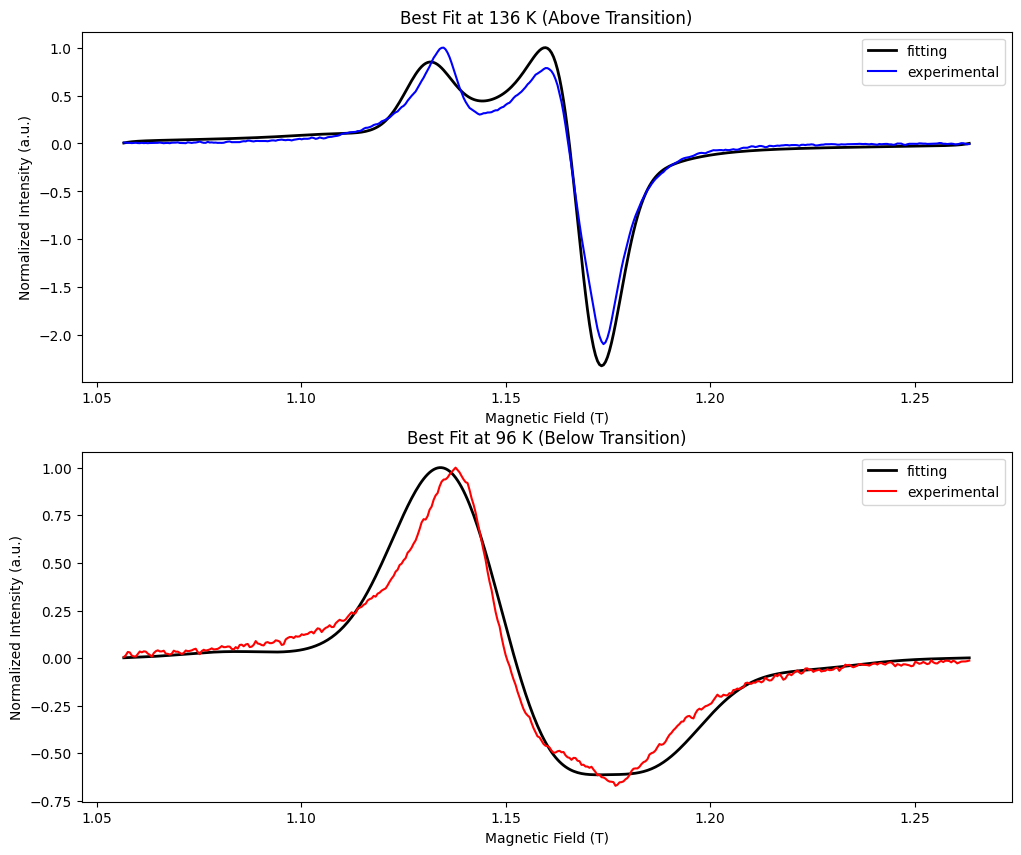

In [15]:
plt.figure(figsize=(12, 10))

# Plot high temperature spectrum (136 K)
plt.subplot(2, 1, 1)
plt.plot(fields_high, new_result.best_spectrum[0].numpy() / new_result.best_spectrum[0].numpy().max(), 'black', linewidth=2.0, label='fitting')
plt.plot(fields_high, y_exp_high, 'b-', linewidth=1.5, label='experimental')
plt.title(f'Best Fit at 136 K (Above Transition)', fontsize=12)
plt.xlabel('Magnetic Field (T)', fontsize=10)
plt.ylabel('Normalized Intensity (a.u.)', fontsize=10)
plt.legend()

# Plot low temperature spectrum (96 K)
plt.subplot(2, 1, 2)
plt.plot(fields_low, new_result.best_spectrum[1].numpy(), 'black', linewidth=2.0, label='fitting')
plt.plot(fields_low, y_exp_low, 'r-', linewidth=1.5, label='experimental')
plt.title(f'Best Fit at 96 K (Below Transition)', fontsize=12)
plt.xlabel('Magnetic Field (T)', fontsize=10)
plt.ylabel('Normalized Intensity (a.u.)', fontsize=10)
plt.legend()

plt.show()

In [16]:
def compute_g_tensor_table(params):
    gx_chain = params['g_cu_chain_x']
    gy_chain = params['g_cu_chain_y']
    gz_chain = params['g_cu_chain_z']
    giso_chain = math.sqrt((gx_chain**2 + gy_chain**2 + gz_chain**2) / 3)

    gx_b_high = params['g_cu_branching_high_temp_x']
    gy_b_high = params['g_cu_branching_high_temp_y']
    gz_b_high = params['g_cu_branching_high_temp_z']
    giso_b_high = math.sqrt((gx_b_high**2 + gy_b_high**2 + gz_b_high**2) / 3)

    gx_b_low = params['g_cu_branching_low_temp_x']
    gz_b_low = params['g_cu_branching_low_temp_z']
    delta_g = params['delta_g']

    g_sq_high = gx_b_high**2 + gy_b_high**2 + gz_b_high**2
    g_sq_low = g_sq_high + delta_g

    gy_sq_low = g_sq_low - gx_b_low**2 - gz_b_low**2
    gy_b_low = math.sqrt(gy_sq_low)
    giso_b_low = math.sqrt(g_sq_low / 3)

    rows = [
        ("chain Cu(II) ion", gx_chain, gy_chain, gz_chain, giso_chain),
        ("branching Cu(II) ion (136 K)", gx_b_high, gy_b_high, gz_b_high, giso_b_high),
        ("branching Cu(II) center (90 K)", gx_b_low, gy_b_low, gz_b_low, giso_b_low),
    ]

    print(f"{'':<30} {'gx':>8} {'gy':>8} {'gz':>8} {'giso':>8}")
    for label, gx, gy, gz, giso in rows:
        print(f"{label:<30} {gx:>8.3f} {gy:>8.3f} {gz:>8.3f} {giso:>8.3f}")

In [17]:
results_original_best_fit = new_result.best_params.copy()
compute_g_tensor_table(results_original_best_fit)

                                     gx       gy       gz     giso
chain Cu(II) ion                  2.032    2.136    2.289    2.155
branching Cu(II) ion (136 K)      2.078    2.112    2.276    2.157
branching Cu(II) center (90 K)    2.114    2.260    2.092    2.157


Here we observe the rotation of the g-tensor in the bracnhing copper from the y-direction to the z-direction.

# 5. Search other solutions

If you look at the dashboard, you'll notice that our model has many local minima. The resulted parameters correlate with each other. Let's catch other possible results

### 5.1. Defining Parameter Searcher

In [18]:
# Create space searcher to find alternative solutions
space_searcher = SpaceSearcher(loss_rel_tol=2.0, distance_fraction=0.2)  # Allow 200% higher loss, cut distances at 0.2 * max_distance

# Define parameters to vary when searching for alternatives
param_names = [
    "g_cu_chain_x", "g_cu_chain_y", "g_cu_chain_z",
    "g_cu_branching_high_temp_x", "g_cu_branching_high_temp_y", "g_cu_branching_high_temp_z",
    "g_cu_branching_low_temp_x", "g_cu_branching_low_temp_z"
]


# Search for alternative solutions
searcher_result = space_searcher(result, param_names)

# Print alternative solutions
print_trial_results(searcher_result[0:4])

TRIAL #1121
index: 0
----------------------------------------
Loss:     0.095161
Distance: 4.984279

PARAMETERS:
----------------------------------------
  g_cu_chain_x               =        2.112102 (Δ +0.079797)
  g_cu_chain_y               =        2.006249 (Δ -0.132852)
  g_cu_chain_z               =        2.270692 (Δ -0.018866)
  g_cu_branching_high_temp_x =        2.218489 (Δ +0.140149)
  g_cu_branching_high_temp_y =        2.197659 (Δ +0.090631)
  g_cu_branching_high_temp_z =        2.148937 (Δ -0.127390)
  g_cu_branching_low_temp_x  =        2.066936 (Δ -0.041572)
  g_cu_branching_low_temp_z  =        2.179931 (Δ +0.092907)
  delta_g                    =        0.001808 (Δ +0.011414)
  lorentz_high_temp          =        0.010712 (Δ +0.006657)
  ham_strain_high_temp       =      1.3336e+08 (Δ -2.0996e+08)
  lorentz_low_temp           =        0.009605 (Δ +0.006868)
  ham_strain_low_temp        =      5.3244e+08 (Δ -2.4269e+08)


TRIAL #1070
index: 1
--------------------------

### 5.2. Fitting in the new local minima

We continue fitting the data from newly identified starting points. The procedure is as follows:

1) We select trial parameters obtained from the global search and use them as initial guesses.

2) We perform local fitting from these new starting points with reduced parameter bounds.

In [ ]:
results_after_space_search = []
# Consider 2 solutions
for trial in searcher_result[:2]:
    new_default_params = trial["params"]

    # Create a refined parameter space
    new_param_space = param_space.copy()
    # Update default values to best parameters found
    new_param_space.set_default(new_default_params)

    # Reduce bounds to focus on promising region (30% of original width)
    new_param_space.reduce_bounds(alpha=0.3)

    # Update the fitter with refined parameter space
    fitter.param_space = new_param_space

    # Run local refinement with COBYLA optimizer
    updated_result = fitter.fit(
        backend="ng", 
        budget=200, 
        optimizer="Cobyla"
    )
    results_after_space_search.append(updated_result)

Let's review the new results. It's okay if some of them aren't as good as we expected. We're defining only one unit of three ions in the Khian system, where the units have different orientations.

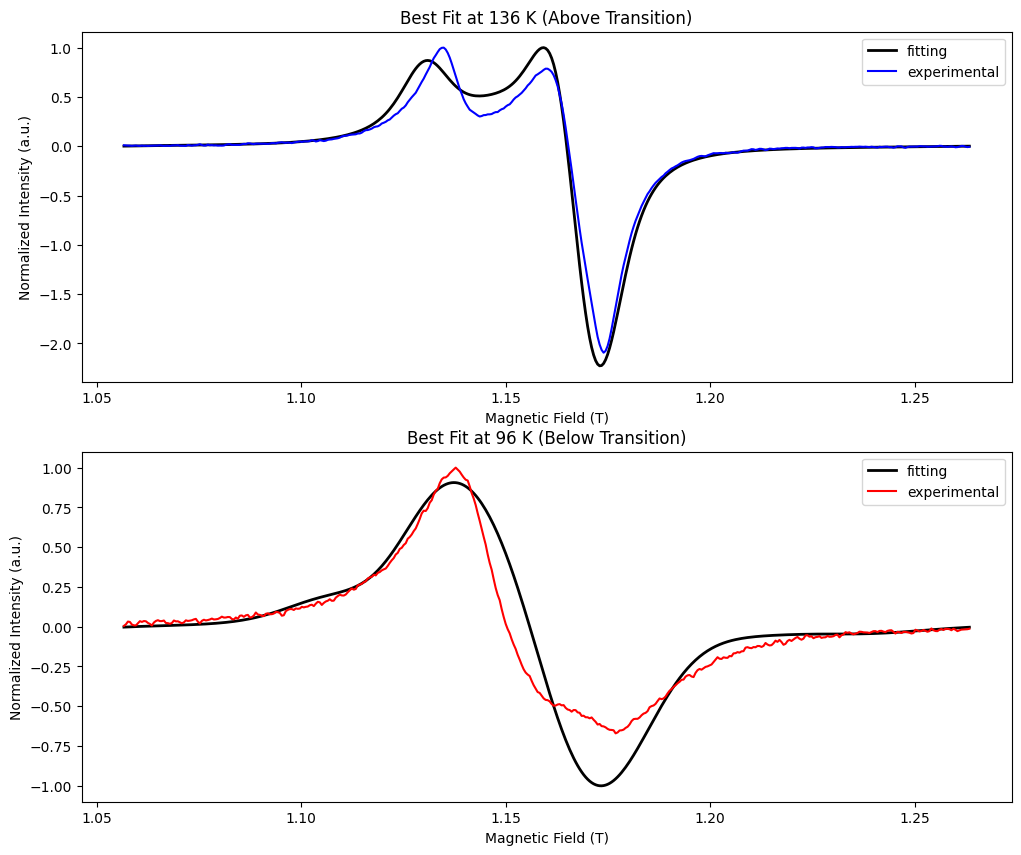

In [27]:
plt.figure(figsize=(12, 10))

new_result = results_after_space_search[1]
# Plot high temperature spectrum (136 K)
plt.subplot(2, 1, 1)
plt.plot(fields_high, new_result.best_spectrum[0].numpy() / new_result.best_spectrum[0].numpy().max(), 'black', linewidth=2.0, label='fitting')
plt.plot(fields_high, y_exp_high, 'b-', linewidth=1.5, label='experimental')
plt.title(f'Best Fit at 136 K (Above Transition)', fontsize=12)
plt.xlabel('Magnetic Field (T)', fontsize=10)
plt.ylabel('Normalized Intensity (a.u.)', fontsize=10)
plt.legend()

# Plot low temperature spectrum (96 K)
plt.subplot(2, 1, 2)
plt.plot(fields_low, new_result.best_spectrum[1].numpy(), 'black', linewidth=2.0, label='fitting')
plt.plot(fields_low, y_exp_low, 'r-', linewidth=1.5, label='experimental')
plt.title(f'Best Fit at 96 K (Below Transition)', fontsize=12)
plt.xlabel('Magnetic Field (T)', fontsize=10)
plt.ylabel('Normalized Intensity (a.u.)', fontsize=10)
plt.legend()

plt.show()

And plot all copper ions g-tesnors.

In [28]:
print("Original best fitting parameters")
compute_g_tensor_table(results_original_best_fit)
print("---------------------------------------------------------------")
print("---------------------------------------------------------------\n")
print("Locally defined best fitting parameters \n")

for i, result in enumerate(results_after_space_search):
    print()
    print(f"updated trial: {i}")
    compute_g_tensor_table(result.best_params)
    

Original best fitting parameters
                                     gx       gy       gz     giso
chain Cu(II) ion                  2.032    2.136    2.289    2.155
branching Cu(II) ion (136 K)      2.078    2.112    2.276    2.157
branching Cu(II) center (90 K)    2.114    2.260    2.092    2.157
---------------------------------------------------------------
---------------------------------------------------------------

Locally defined best fitting parameters 


updated trial: 0
                                     gx       gy       gz     giso
chain Cu(II) ion                  2.103    2.018    2.271    2.133
branching Cu(II) ion (136 K)      2.213    2.191    2.148    2.184
branching Cu(II) center (90 K)    2.062    2.284    2.202    2.184

updated trial: 1
                                     gx       gy       gz     giso
chain Cu(II) ion                  2.115    2.024    2.283    2.144
branching Cu(II) ion (136 K)      2.189    2.196    2.131    2.172
branching Cu(II) center